In [ ]:
dname = 'dataset1'

In [ ]:
TR_ITER = 10001
TR_AVG_ITER = 2500

In [ ]:
EXP_NAME = 'testing_pickle1'

In [ ]:
# Path to load data fro
BASE_DIR = ''

In [ ]:
SAVE_DIR = ''

# Func

In [ ]:
from datetime import datetime


In [ ]:
import time
start = time.time()

In [ ]:
import os


In [ ]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats
import pandas as pd

In [ ]:
import tensorflow as tf
import tensorflow_probability as tfp

In [ ]:
from xgboost import XGBClassifier
from xgboost import XGBRegressor
from scipy.linalg import null_space
from sklearn.cross_decomposition import CCA
from sklearn.ensemble import RandomForestClassifier
from scipy.spatial.distance import cdist
from sklearn.linear_model import LogisticRegression

In [ ]:
from scipy.integrate import trapezoid
from sklearn import metrics

def auprc_threshs(confidences, Y, threshs, as_percentages=True):
  areas = []
  precisions, recalls, thresholds = metrics.precision_recall_curve(Y, confidences)
  for t in threshs:
    if t < 1.0:
      interp_prec_t = np.interp(t, recalls[::-1], precisions[::-1])
      recalls_thresh = np.concatenate(([t], recalls[recalls<t]))
      precisions_thresh = np.concatenate(([interp_prec_t], precisions[recalls<t]))
    else:
      recalls_thresh = recalls
      precisions_thresh = precisions
    area_t = metrics.auc(recalls_thresh, precisions_thresh)
    if as_percentages:
      area_t = area_t/t
    areas.append(area_t)
  return np.array(areas)

In [ ]:
external_colstart = 4 if dname in set(['dataset1', 'dataset2', 'dataset3', 'dataset4']) else 2  # SHOULD BE 4 for 'dataset1' ... 'dataset4' otherwise 2

In [ ]:
with open(os.path.join(BASE_DIR, dname, 'train.csv'), 'r') as f:
  dataX = np.float32(np.array([line.strip().split(',')[2:] for line in f])[1:])

with open(os.path.join(BASE_DIR, dname, 'train.csv'), 'r') as f:
  dataY = np.float32(np.array([line.strip().split(',')[1] for line in f])[1:])

X = dataX
Y = dataY

In [ ]:
with open(os.path.join(BASE_DIR, dname, 'val_id.csv'), 'r') as f:
  dataX_val = np.float32(np.array([line.strip().split(',')[2:] for line in f])[1:])

with open(os.path.join(BASE_DIR, dname, 'val_id.csv'), 'r') as f:
  dataY_val = np.float32(np.array([line.strip().split(',')[1] for line in f])[1:])

In [ ]:
with open(os.path.join(BASE_DIR, dname, 'test_id.csv'), 'r') as f:
  dataX_tst = np.float32(np.array([line.strip().split(',')[2:] for line in f])[1:])

with open(os.path.join(BASE_DIR, dname, 'test_id.csv'), 'r') as f:
  dataY_tst = np.float32(np.array([line.strip().split(',')[1] for line in f])[1:])

In [ ]:
with open(os.path.join(BASE_DIR, dname, 'val_ood.csv'), 'r') as f:
  external_X = np.float32(np.array([line.strip().split(',')[external_colstart:] for line in f])[1:])

with open(os.path.join(BASE_DIR, dname, 'val_ood.csv'), 'r') as f:
  external_Y = np.float32(np.array([line.strip().split(',')[1] for line in f])[1:])

In [ ]:
X = dataX
Y = dataY

# standardize the data
mu_x = np.mean(X, 0, keepdims=True)
#sigma_x = np.std(X, 0, keepdims=True)
sigma_x = np.ones_like(mu_x)
X = (X-mu_x)/sigma_x

# PCA
XtX = np.matmul(X.T, X)
eigvals, eigvecs = np.linalg.eig(XtX)
sortinds = np.argsort(-eigvals)
V = eigvecs[:, sortinds]

In [ ]:
external_X = (external_X-mu_x)/sigma_x
# held_X = (dataX_val-mu_x)/sigma_x
# held_Y = dataY_val
held_X = (np.concatenate((dataX_val, dataX_tst), 0)-mu_x)/sigma_x
held_Y = np.concatenate((dataY_val, dataY_tst), 0)

In [ ]:
NDIRS = 128  # 256
X = X@V[:, :NDIRS]
held_X = held_X@V[:, :NDIRS]
external_X = external_X@V[:, :NDIRS]

In [ ]:
def get_preds(x, ests, mus=None, dirs=None, use_proba=False):
  if mus is None:
    mus = [0.0 for _ in range(len(ests))]
  if dirs is not None:
    if use_proba:
      pred_array = [e.predict_proba((x-mu)@d)[:, 1] for mu, d, e in zip(mus, dirs, ests)]
    else:
      pred_array = [e.predict((x-mu)@d) for mu, d, e in zip(mus, dirs, ests)]
  else:
    if use_proba:
      pred_array = [e.predict_proba((x-mu))[:, 1] for mu, e in zip(mus, ests)]
    else:
      pred_array = [e.predict((x-mu)) for mu, e in zip(mus, ests)]
  return np.stack(pred_array, -1)

In [ ]:
def aggregate_preds(preds, use_bernoulli_std=False):
  mean_pred = np.mean(preds, 1, keepdims=False)
  if use_bernoulli_std:
    std_pred = mean_pred*(1-mean_pred)
  else:
    std_pred = np.std(preds, 1, keepdims=False)
  return np.float32(mean_pred>0.5), mean_pred, std_pred

Train on random directions

In [ ]:
from sklearn.metrics import precision_score

In [ ]:
def divide_points(percentage_threshold, X, y, index):
  dot_products = (X @ X[index, None, :].T)[:, 0]
  thresh = np.quantile(dot_products, 1.-percentage_threshold)
  # id_x, id_y, ood_x, ood_y
  return (X[dot_products<thresh], y[dot_products<thresh],
    X[dot_products>=thresh], y[dot_products>=thresh])


In [ ]:
from abc import ABC, abstractmethod

In [ ]:
class Ensemble(ABC):
  """ General Ensembling Class """

  @abstractmethod
  def __init__(self, *args, **kwargs):
    self.nmodels = kwargs.get('nmodels', 256)

  @property
  @abstractmethod
  def estimators(self):
    pass

  @abstractmethod
  def add_estimator(self, est):
    pass

  @abstractmethod
  def base_model_generator(self):
    # Returns something trainable with fit(X,Y)
    pass

  def random_sample(self, X, Y):
    # Potentially subsample X and Y
    return X, Y

  def fit(self, X, Y, verbose=True):
    # Returns something trainable with fit(X,Y)
    for t in range(self.nmodels):
      sX, sY = self.random_sample(X, Y)
      est = self.base_model_generator()
      if verbose:
        print('Fitting Model {}'.format(t))
      est.fit(sX, sY)
      self.add_estimator(est)

  def predictions(self, x):
    # Assumes estimators return (N, ) shape predict
    pred_array = [e.predict(x) for e in self.estimators]
    return np.stack(pred_array, -1)

  def predict(self, x=None, preds=None, return_only_prediction=True):
    assert (x is not None) or (preds is not None)
    if preds is None:
      preds = self.predictions(x)

    mean_pred = np.mean(preds, 1, keepdims=False)
    std_pred = np.std(preds, 1, keepdims=False)

    if return_only_prediction:
      return np.float32(mean_pred>0.5)
    return np.float32(mean_pred>0.5), mean_pred, std_pred

In [ ]:
class ProjectionEnsemble(Ensemble):
  """ General Ensembling Class With Projections of Dimensions"""

  @abstractmethod
  def __init__(self, *args, **kwargs):
    super(ProjectionEnsemble, self).__init__(*args, **kwargs)

  @property
  @abstractmethod
  def directions(self):
    pass

  @property
  @abstractmethod
  def means(self):
    pass

  def predictions(self, x):
    # Assumes estimators return (N, ) shape predict
    pred_array = [
      e.predict((x-mu)@d)
      for mu, d, e in zip(self.means, self.directions, self.estimators)
    ]
    return np.stack(pred_array, -1)

In [ ]:
class PCAProjectionEnsemble(ProjectionEnsemble):
  """ General Ensembling Class With Projections of Dimensions"""

  def __init__(self, *args, **kwargs):
    super(ProjectionEnsemble, self).__init__(*args, **kwargs)
    self.ndirs = kwargs.get('ndirs', 8)
    self.Vpca = kwargs['Vpca']  # d x k
    self.Vorth = kwargs.get('Vorth', 8)
    self.projection_split = kwargs.get('projection_split', False)
    self.split_perc = kwargs.get('split_perc', .5)
    self._splits_rand = []
    self._dirs_inds = []
    self._estimators = []

  @property
  def directions(self):
    return [self.Vpca[:, dinds] for dinds in self._dirs_inds]

  @property
  def means(self):
    return [np.zeros((1, self.Vpca.shape[0]), dtype=np.float32)] * len(self._dirs_inds)

  @property
  def estimators(self):
    return self._estimators

  def add_estimator(self, est):
    self._estimators.append(est)

  def base_model_generator(self):
    # Returns something trainable with fit(X,Y)
    # TODO: make init argument
    return XGBClassifier(n_estimators=40)

  def random_sample(self, X, Y, XV=None):
    # Potentially subsample X and Y
    N_tot, d = X.shape

    if self.projection_split:
      newdir = np.random.randn(d, 1)
      newdir = newdir/np.sqrt(np.sum(newdir**2))
      projs = (X@newdir)[:, 0]
      medianp = np.median(projs)
      in_range = projs <= medianp
    else:
      in_range = np.random.rand(N_tot) <= self.split_perc
    self._splits_rand.append(in_range)

    Y_train = Y[in_range]
    rprm = np.random.permutation(self.Vpca.shape[1])
    self._dirs_inds.append(rprm[:self.ndirs])
    if XV is not None:
      X_train = XV[in_range][:, self._dirs_inds[-1]]
    else:
      X_train = X[in_range]@self.Vpca[:, self._dirs_inds[-1]]

    return X_train, Y_train

  def fit(self, X, Y, verbose=True):
    XV = X@self.Vpca
    for t in range(self.nmodels):
      sX, sY = self.random_sample(X, Y, XV)
      est = self.base_model_generator()
      if verbose:
        print('Fitting Model {}'.format(t))
      est.fit(sX, sY)
      self.add_estimator(est)

  def predictions(self, x):
    xV = x@self.Vpca
    # Assumes estimators return (N, ) shape predict
    pred_array = [
      e.predict(xV[:, di])
      for di, e in zip(self._dirs_inds, self.estimators)
    ]
    return np.stack(pred_array, -1)

In [ ]:
# with open(os.path.join(BASE_DIR +'/' + EXP_NAME + '/' + dname, 'pca_projens_1024.p'), 'rb') as f:
#     pca_proj = pickle.load(f)

In [ ]:
def knn_gibbs(Xsamp, X, nn_featinds, k):
  Xf = X[:, nn_featinds]
  Xsf = Xsamp[:, nn_featinds]
  Xfnorm2 = np.sum(Xf**2, keepdims=True)
  Xsfnorm2 = np.sum(Xsf**2, keepdims=True)
  dotsf = Xsf@Xf.T
  distsf = Xsfnorm2 + Xfnorm2.T - 2*dotsf
  sortdistsf = np.argsort(distsf, axis=1)
  # neighs = sortdistsf[:, np.random.choice(k, size=(X.shape[0], ))]
  neighs = sortdistsf[np.arange(Xsamp.shape[0]), np.random.choice(k, size=(X.shape[0], ))]
  Xsamp = np.copy(Xsamp)
  Xsamp[:, np.logical_not(nn_featinds)] = X[neighs, :][:, np.logical_not(nn_featinds)]
  return Xsamp

def gibbs_sample(X, k, nrounds):
  Xsamp = X
  for r in range(nrounds):
    featinds = np.random.rand(X.shape[1])<.5
    Xsamp = knn_gibbs(Xsamp, X, featinds, k)
    Xsamp = knn_gibbs(Xsamp, X, np.logical_not(featinds), k)
  return Xsamp

def permute_expand(X):
  N, d = X.shape
  return np.stack([X[np.random.permutation(N), i] for i in range(d)], -1)

def convex_expand(X):
  N, d = X.shape
  X1 = X[np.random.permutation(N), :]
  alphas = np.random.rand(N, 1)
  return alphas*X + (1-alphas)*X1

In [ ]:
expand_funcs = [
    # lambda x: gibbs_sample(x, 40, 2),
    # lambda x: permute_expand(x),
    # lambda x: convex_expand(x),
    lambda x: x*(1+np.abs(np.random.randn(x.shape[0], 1)))
]

In [ ]:
class DatasetDiscriminator(tf.keras.Model):
  def __init__(self, dim, nhidden_layers=2, hidden_size=256, out_size=64, net=None):
    super(DatasetDiscriminator, self).__init__()

    self.dim = dim
    if net is not None:
      self.net = net
    else:
      layers = [
        tf.keras.layers.Dense(
            hidden_size, activation=tf.nn.elu) for _ in range(nhidden_layers)] + \
            [tf.keras.layers.Dense(out_size)]
      self.net = tf.keras.Sequential(layers)

    # self.beta = tf.Variable(
    #  tf.random.normal([out_size, 1], stddev=0.01), name='beta')

  def get_features(self, x_in):
    # print(x_in.shape)
    feats = self.net(x_in)
    # print(feats.shape)
    return feats

  def __call__(self, x_in):
    return self.get_features(x_in)

  def predictions(self, x_in):
    return tf.nn.sigmoid(self.get_features(x_in))


  def predictions_via_logits(self, x_in):
    return tf.nn.sigmoid(np.mean(self.get_features(x_in), -1))

  # def get_logits(self, x_in):
  #   return tf.matmul(self.get_features(x_in), self.beta)

In [ ]:
def smooth_maximum(v, temp=1.0):
  softmaxv = tf.nn.softmax(v/temp, axis=-1)
  return tf.reduce_sum(v*softmaxv, axis=-1, keepdims=True)

In [ ]:
def sigmoid_entropy(logits, normalize=False):
  NORM = 0.6931471805599453  # -np.log(.5)
  p = tf.nn.sigmoid(logits)
  entropy = p*tf.nn.softplus(-logits) + (1.-p)*tf.nn.softplus(logits)
  if normalize:
    return entropy/NORM
  return entropy

In [ ]:
def training_batch(data, llks, batchsize):
  def generate_batch():
    rprm_in = np.random.permutation(data.shape[0])
    if len(llks.shape)==1:
      return data[rprm_in[:batchsize], :], llks[rprm_in[:batchsize], None]
    return data[rprm_in[:batchsize], :], llks[rprm_in[:batchsize]]
  return generate_batch

# NT EMOE

In [ ]:
pca_proj = PCAProjectionEnsemble(nmodels=2**10, ndirs=64, Vpca=np.eye(NDIRS, dtype=np.float32))
pca_proj.fit(X, Y)
# with open(os.path.join(BASE_DIR +'/' + EXP_NAME + '/' + dname, 'EMOE_pca_projens.p'), 'wb') as f:
#     pickle.dump(pca_proj, f)

Fitting Model 0
Fitting Model 1
Fitting Model 2
Fitting Model 3
Fitting Model 4
Fitting Model 5
Fitting Model 6
Fitting Model 7
Fitting Model 8
Fitting Model 9
Fitting Model 10
Fitting Model 11
Fitting Model 12
Fitting Model 13
Fitting Model 14
Fitting Model 15
Fitting Model 16
Fitting Model 17
Fitting Model 18
Fitting Model 19
Fitting Model 20
Fitting Model 21
Fitting Model 22
Fitting Model 23
Fitting Model 24
Fitting Model 25
Fitting Model 26
Fitting Model 27
Fitting Model 28
Fitting Model 29
Fitting Model 30
Fitting Model 31
Fitting Model 32
Fitting Model 33
Fitting Model 34
Fitting Model 35
Fitting Model 36
Fitting Model 37
Fitting Model 38
Fitting Model 39
Fitting Model 40
Fitting Model 41
Fitting Model 42
Fitting Model 43
Fitting Model 44
Fitting Model 45
Fitting Model 46
Fitting Model 47
Fitting Model 48
Fitting Model 49
Fitting Model 50
Fitting Model 51
Fitting Model 52
Fitting Model 53
Fitting Model 54
Fitting Model 55
Fitting Model 56
Fitting Model 57
Fitting Model 58
Fitting

In [ ]:
from datetime import datetime
now = datetime.now()
dt_string = now.strftime('%Y-%m-%d_%H:%M:%S')
print(dt_string)

2025-01-22_02:32:20


In [ ]:
X_train = X  # X[~train_low_conf_ind]
labels_train = Y[:, None]  # Y[~train_low_conf_ind, None]

train_predictions = pca_proj.predictions(X)
train_ens_preds, train_mp, train_sp = pca_proj.predict(preds=train_predictions, return_only_prediction=False)

In [ ]:
expand_funcs = [
    # # lambda x: gibbs_sample(x, 40, 2),
    # lambda x: permute_expand(x),
    # lambda x: convex_expand(x),
    lambda x: x*(1+np.abs(np.random.randn(x.shape[0], 1)))
]

In [ ]:
conf_range = .1
conf_expX = []
conf_exppreds = []
unconf_expX = []
unconf_exppreds = []
all_expX = []
all_exppreds = []
for dexptrl in range(5):
  print('[[[[[[[[[[[[[[[[[[[[[[  {}  ]]]]]]]]]]]]]]]]]]]]]]'.format(dexptrl))
  for trnd, expfunc in enumerate(expand_funcs):
    print('>>>>>>>>{}'.format(trnd))

    expanded_X = expfunc(X)
    preds_exp = pca_proj.predictions(expanded_X)
    ens_preds_exp, mp_exp, sp_exp = pca_proj.predict(preds=preds_exp, return_only_prediction=False)

    high_conf_ind = np.logical_or(
      np.greater(mp_exp, 1-conf_range/2), np.less(mp_exp, conf_range/2))
    conf_expX.append(expanded_X[high_conf_ind])
    conf_exppreds.append(preds_exp[high_conf_ind])

[[[[[[[[[[[[[[[[[[[[[[  0  ]]]]]]]]]]]]]]]]]]]]]]
>>>>>>>>0
>>>>>>>>1
>>>>>>>>2
[[[[[[[[[[[[[[[[[[[[[[  1  ]]]]]]]]]]]]]]]]]]]]]]
>>>>>>>>0
>>>>>>>>1
>>>>>>>>2
[[[[[[[[[[[[[[[[[[[[[[  2  ]]]]]]]]]]]]]]]]]]]]]]
>>>>>>>>0
>>>>>>>>1
>>>>>>>>2
[[[[[[[[[[[[[[[[[[[[[[  3  ]]]]]]]]]]]]]]]]]]]]]]
>>>>>>>>0
>>>>>>>>1
>>>>>>>>2
[[[[[[[[[[[[[[[[[[[[[[  4  ]]]]]]]]]]]]]]]]]]]]]]
>>>>>>>>0
>>>>>>>>1
>>>>>>>>2


In [ ]:
conf_expX = np.concatenate(conf_expX, 0)
conf_exppreds = np.concatenate(conf_exppreds, 0)

## RUN Tiny EMEO

In [ ]:
def loss(model, inputs, labels, inputs_conf, labels_conf, alpha=0.5):
  # inputs_unconf_logits = model.get_features(inputs_unconf)
  # inputs_unconf_sigmoids = tf.nn.sigmoid(inputs_unconf_logits)
  # Encourage diversity by minimizing probability distribution innerproducts
  # p*q + (1-p)(1-q) = 1 - p - q + 2*p*q
  # Note: encouraging diversity for low confidence instances, to minimize dependencies on errors
  # WRT existing previous experts
  # pw_prods = 1. - inputs_unconf_sigmoids - labels_unconf + 2.*inputs_unconf_sigmoids*labels_unconf  # N x nexps
  # diversity_loss = tf.reduce_mean(tf.reduce_mean(pw_prods, -1))
  diversity_loss = 0.0

  # uncertainty_loss = .5*tf.reduce_mean(
  #   tf.abs(tf.reduce_mean(inputs_unconf_sigmoids, -1)-.5)) + \
  #   .5*tf.reduce_mean(
  #     tf.abs(tf.reduce_mean(inputs_unconf_sigmoids, 0)-.5))
  # mean_axis1 = tf.reduce_mean(inputs_unconf_sigmoids, -1, keepdims=True)
  # var_axis1 = tf.reduce_mean(
  #   tf.reduce_mean((inputs_unconf_sigmoids-mean_axis1)**2, -1))
  # mean_axis0 = tf.reduce_mean(inputs_unconf_sigmoids, 0, keepdims=True)
  # var_axis0 = tf.reduce_mean(
  #   tf.reduce_mean((inputs_unconf_sigmoids-mean_axis0)**2, 0))
  # uncertainty_loss = -.5*(var_axis0 + var_axis1)  # increase variances
  uncertainty_loss = 0.0

  conf_logits = model.get_features(inputs_conf)
  conf_ce_loss = tf.reduce_mean(
    tf.keras.losses.binary_crossentropy(labels_conf, conf_logits, from_logits=True))
  conf_prob_loss = tf.reduce_mean(tf.abs(
    tf.reduce_mean(tf.nn.sigmoid(conf_logits), 1, keepdims=True) - tf.reduce_mean(labels_conf, 1, keepdims=True)
  ))
  conf_loss = conf_ce_loss  # + conf_prob_loss

  in_logits = model.get_features(inputs)
  in_ce_loss = tf.reduce_mean(
    tf.keras.losses.binary_crossentropy(labels, in_logits, from_logits=True))
  in_prob_loss = tf.reduce_mean(tf.abs(
    tf.reduce_mean(tf.nn.sigmoid(in_logits), 1, keepdims=True) - tf.reduce_mean(labels, 1, keepdims=True)
  ))
  in_loss = in_ce_loss + in_prob_loss
  return in_loss + alpha*conf_loss + diversity_loss + uncertainty_loss

def grad(model, inputs, labels, inputs_conf, labels_conf, alpha=0.5):
  with tf.GradientTape() as tape:
    loss_value = loss(model, inputs, labels, inputs_conf, labels_conf, alpha=alpha)
  return tape.gradient(loss_value, model.trainable_variables)

steps = TR_ITER
#optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)
bsize = 256
# model = DatasetDiscriminator(dim=X.shape[0], hidden_size=512, nhidden_layers=2, out_size=train_predictions.shape[1])

avgint = TR_AVG_ITER

conf_thresh = .4
alpha_rnd = .5
print(alpha_rnd)
# critical_X = critical_ood[np.random.permutation(critical_ood.shape[0])[:X.shape[0]]]
# critical_X = critical_ood[np.random.permutation(critical_ood.shape[0])[:1000]]
# critical_X = critical_ood
expanded_X = X*(1+np.abs(np.random.randn(X.shape[0], 1)))
expanded_predictions = pca_proj.predictions(expanded_X)
expanded_ens_preds, expanded_mp, expanded_sp = pca_proj.predict(expanded_X, preds=expanded_predictions, return_only_prediction=False)
expanded_X = expanded_X[np.abs(expanded_mp-.5)>conf_thresh]
expanded_predictions = expanded_predictions[np.abs(expanded_mp-.5)>conf_thresh]

batch = training_batch(
  X_train,  # np.concatenate((X_train, conf_expX), 0),
  np.float32(train_predictions),  #np.concatenate((np.float32(labels_train), np.float32(conf_exppreds)), 0),
  bsize)
batch_conf = training_batch(
  np.concatenate((conf_expX, expanded_X), 0), # expanded_X,
  np.float32(np.concatenate((conf_exppreds, expanded_predictions), 0)),
  bsize)
batch_unconf = training_batch(
  unconf_expX,
  np.float32(unconf_exppreds),
  bsize)
# conf_lbls = np.concatenate((train_predictions, expanded_predictions), 0)
# batch_conf = training_batch(
#   np.concatenate((X, expanded_X), 0),
#   conf_lbls,  # (conf_lbls-np.min(conf_lbls))/(np.max(conf_lbls)-np.min(conf_lbls)),
#   bsize)

xb, xlbls = batch()
xb_conf, xlbls_conf = batch_conf()
# xb_unconf, xlbls_unconf = batch_unconf()
# TODO: consider new model each round?
T = 0
model = DatasetDiscriminator(dim=X.shape[0], hidden_size=32, nhidden_layers=2, out_size=train_predictions.shape[1])
average_model = DatasetDiscriminator(dim=X.shape[0], hidden_size=32, nhidden_layers=2, out_size=train_predictions.shape[1])
optimizer = tf.keras.optimizers.Adam(learning_rate=0.0005)
print("Loss at step {:03d}: {:.3f}".format(-1, loss(model, xb, xlbls, xb_conf, xlbls_conf, alpha=alpha_rnd)))
print("Loss at step {:03d}: {:.3f}".format(-1, loss(average_model, xb, xlbls, xb_conf, xlbls_conf, alpha=alpha_rnd)))
for i in range(steps):
  xb, xlbls = batch()
  xb_conf, xlbls_conf = batch_conf()
  # xb_unconf, xlbls_unconf = batch_unconf()
  grads = grad(model, xb, xlbls, xb_conf, xlbls_conf, alpha=alpha_rnd)
  optimizer.apply_gradients(zip(grads, model.trainable_variables))
  if i % 1000 == 0:
    print("Loss at step {:03d}: {:.3f}".format(i, loss(model, xb, xlbls, xb_conf, xlbls_conf, alpha=alpha_rnd)))
  if i > 0 and i % avgint == 0:
    print('Getting Average Model (T={})'.format(T))
    for avgweights, weights in zip(average_model.trainable_variables, model.trainable_variables):
      avgweights.assign((T/(T+1.))*avgweights + (1./(T+1))*weights)
    T = T + 1



0.5
Loss at step -01: 1.515
Loss at step -01: 1.518
Loss at step 000: 1.523
Loss at step 1000: 0.230
Loss at step 2000: 0.179
Getting Average Model (T=0)
Loss at step 3000: 0.219
Loss at step 4000: 0.159
Loss at step 5000: 0.136
Getting Average Model (T=1)
Loss at step 6000: 0.136
Loss at step 7000: 0.160
Getting Average Model (T=2)
Loss at step 8000: 0.182
Loss at step 9000: 0.205
Loss at step 10000: 0.162
Getting Average Model (T=3)


In [ ]:
AUCTHRESHS = [0.1, 0.2, 0.3, 0.4, 1]

In [ ]:
end = time.time()
length = end - start

In [ ]:
print("It took", length, "seconds!")

It took 1061.5244574546814 seconds!


In [ ]:
save_path = os.path.join(SAVE_DIR, dname, dt_string)

In [ ]:
os.makedirs(save_path, exist_ok=True)

In [ ]:
models_dict = {}
models_dict['base'] = pca_proj
models_dict['model_net'] = model.net
models_dict['avg_model_net'] = average_model.net

In [ ]:
with open(os.path.join(save_path, 'models.p'), 'wb') as f:
    pickle.dump(models_dict, f)

In [ ]:
model.get_features(external_X).shape

TensorShape([7392, 1024])

In [ ]:
predictions_dict = {}
predictions_dict['heldid_Y'] = held_Y
predictions_dict['heldid_base'] = pca_proj.predictions(held_X)
predictions_dict['heldid_model_net'] = model.predictions(held_X)
predictions_dict['heldid_avg_model_net'] = average_model.predictions(held_X)
predictions_dict['heldood_Y'] = external_Y
predictions_dict['heldood_base'] = pca_proj.predictions(external_X)
predictions_dict['heldood_model_net'] = model.predictions(external_X)
predictions_dict['heldood_avg_model_net'] = average_model.predictions(external_X)

In [ ]:
with open(os.path.join(save_path, 'predictions.p'), 'wb') as f:
    pickle.dump(predictions_dict, f)

In [ ]:
results_dict = {}
results_dict['threshs'] = AUCTHRESHS

Base:
[0.99934591 0.99869182 0.99803773 0.99738363 0.98615538] (AUROC:0.8792977845915576,ACC:0.9092458884877658)
Model:
[0.99685077 0.99636725 0.99602944 0.99541868 0.98322942] (AUROC:0.868830309384008,ACC:0.9108503810669876)
Average Model:
[0.9941475  0.9941168  0.99380902 0.99356101 0.98232302] (AUROC:0.8674111376797674,ACC:0.9122543120738067)
Base+Model:
[0.99664381 0.99645522 0.99645914 0.99625005 0.98539759] (AUROC:0.8830108864584355,ACC:0.9119534697152025)
Base+Average Model:
[0.99454299 0.99503082 0.99512763 0.99509648 0.98457102] (AUROC:0.8802508841220532,ACC:0.9107501002807862)


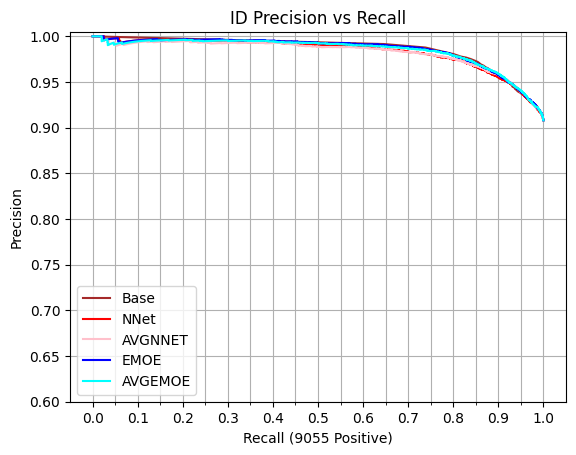

In [ ]:
# plot id
###########
base_predictions = predictions_dict['heldid_base']
model_predictions = predictions_dict['heldid_model_net']
average_model_predictions = predictions_dict['heldid_avg_model_net']
true_Y = predictions_dict['heldid_Y']

plt.figure()

# base model
confs = np.mean(base_predictions, -1)
preds = (confs >.5)
precision, recall, thresholds = metrics.precision_recall_curve(true_Y, confs)
plt.plot(recall, precision, c='brown')
BASE_AUPRC = auprc_threshs(confs, true_Y, AUCTHRESHS)
BASE_AUROC = metrics.roc_auc_score(true_Y, confs)
BASE_ACC = metrics.accuracy_score(true_Y, preds)

print('Base:\n{} (AUROC:{},ACC:{})'.format(BASE_AUPRC, BASE_AUROC,BASE_ACC))

# student model
confs = np.mean(model_predictions, -1)
preds = (confs >.5)
precision, recall, thresholds = metrics.precision_recall_curve(true_Y, confs)
plt.plot(recall, precision, c='red')
MOD_AUPRC = auprc_threshs(confs, true_Y, AUCTHRESHS)
MOD_AUROC = metrics.roc_auc_score(true_Y, confs)
MOD_ACC = metrics.accuracy_score(true_Y, preds)
print('Model:\n{} (AUROC:{},ACC:{})'.format(MOD_AUPRC, MOD_AUROC,MOD_ACC))

# average student model
confs = np.mean(average_model_predictions, -1)
preds = (confs >.5)
precision, recall, thresholds = metrics.precision_recall_curve(true_Y, confs)
plt.plot(recall, precision, c='pink')
AVGMOD_AUPRC = auprc_threshs(confs, true_Y, AUCTHRESHS)
AVGMOD_AUROC = metrics.roc_auc_score(true_Y, confs)
AVGMOD_ACC = metrics.accuracy_score(true_Y, preds)
print('Average Model:\n{} (AUROC:{},ACC:{})'.format(AVGMOD_AUPRC, AVGMOD_AUROC,AVGMOD_ACC))

# base+student model
confs = (np.mean(base_predictions, -1)+np.mean(model_predictions, -1))/2.
preds = (confs >.5)
precision, recall, thresholds = metrics.precision_recall_curve(true_Y, confs)
plt.plot(recall, precision, c='blue')
EMOE_AUPRC = auprc_threshs(confs, true_Y, AUCTHRESHS)
EMOE_AUROC = metrics.roc_auc_score(true_Y, confs)
EMOE_ACC = metrics.accuracy_score(true_Y, preds)
print('Base+Model:\n{} (AUROC:{},ACC:{})'.format(EMOE_AUPRC, EMOE_AUROC,EMOE_ACC))

# base+average student model
confs = (np.mean(base_predictions, -1)+np.mean(average_model_predictions, -1))/2.
preds = (confs >.5)
precision, recall, thresholds = metrics.precision_recall_curve(true_Y, confs)
plt.plot(recall, precision, c='cyan')
AVGEMOE_AUPRC = auprc_threshs(confs, true_Y, AUCTHRESHS)
AVGEMOE_AUROC = metrics.roc_auc_score(true_Y, confs)
AVGEMOE_ACC = metrics.accuracy_score(true_Y, preds)
print('Base+Average Model:\n{} (AUROC:{},ACC:{})'.format(AVGEMOE_AUPRC, AVGEMOE_AUROC,AVGEMOE_ACC))

plt.xticks(np.arange(0, 1.01, step=0.1))
plt.xticks(np.arange(0, 1.01, step=0.05), minor=True)
plt.yticks(np.arange(0.6, 1.01, step=0.05))
plt.grid(True, which='both')
plt.xlabel('Recall ({} Positive)'.format(int(np.sum(true_Y))))
plt.ylabel('Precision')
plt.title('ID Precision vs Recall')
plt.legend(['Base', 'NNet', 'AVGNNET', 'EMOE', 'AVGEMOE'])
plt.show()

In [ ]:
results_dict['heldid_base_AUPRC'] = BASE_AUPRC
results_dict['heldid_model_AUPRC'] = MOD_AUPRC
results_dict['heldid_avg_model_AUPRC'] = AVGMOD_AUPRC
results_dict['heldid_emoe_AUPRC'] = EMOE_AUPRC
results_dict['heldid_avg_emoe_AUPRC'] = AVGEMOE_AUPRC

results_dict['heldid_base_AUROC'] = BASE_AUROC
results_dict['heldid_model_AUROC'] = MOD_AUROC
results_dict['heldid_avg_model_AUROC'] = AVGMOD_AUROC
results_dict['heldid_emoe_AUROC'] = EMOE_AUROC
results_dict['heldid_avg_emoe_AUROC'] = AVGEMOE_AUROC

Base:
[0.98978626 0.97957253 0.97123953 0.96371758 0.91160392] (AUROC:0.7001263008870153,ACC:0.8158820346320347)
Model:
[0.97229201 0.96298288 0.95304496 0.94442465 0.89961754] (AUROC:0.6806948730566995,ACC:0.8058712121212122)
Average Model:
[0.97738618 0.96631571 0.95793361 0.95015054 0.90271913] (AUROC:0.6849178923024337,ACC:0.8110119047619048)
Base+Model:
[0.9879569  0.97780064 0.9681153  0.95912635 0.9084658 ] (AUROC:0.6960897633252283,ACC:0.8158820346320347)
Base+Average Model:
[0.98755189 0.97715961 0.96852404 0.9602149  0.90913937] (AUROC:0.6971072612101128,ACC:0.8168290043290043)


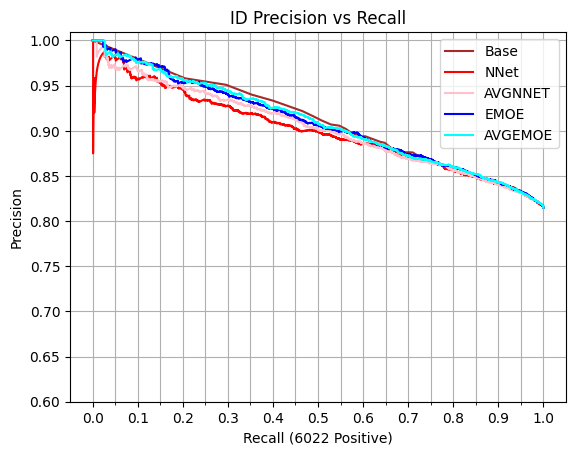

In [ ]:
# plot ood
###########
base_predictions = predictions_dict['heldood_base']
model_predictions = predictions_dict['heldood_model_net']
average_model_predictions = predictions_dict['heldood_avg_model_net']
true_Y = predictions_dict['heldood_Y']

plt.figure()

# base model
confs = np.mean(base_predictions, -1)
preds = (confs >.5)
precision, recall, thresholds = metrics.precision_recall_curve(true_Y, confs)
plt.plot(recall, precision, c='brown')
BASE_AUPRC = auprc_threshs(confs, true_Y, AUCTHRESHS)
BASE_AUROC = metrics.roc_auc_score(true_Y, confs)
BASE_ACC = metrics.accuracy_score(true_Y, preds)

print('Base:\n{} (AUROC:{},ACC:{})'.format(BASE_AUPRC, BASE_AUROC,BASE_ACC))

# student model
confs = np.mean(model_predictions, -1)
preds = (confs >.5)
precision, recall, thresholds = metrics.precision_recall_curve(true_Y, confs)
plt.plot(recall, precision, c='red')
MOD_AUPRC = auprc_threshs(confs, true_Y, AUCTHRESHS)
MOD_AUROC = metrics.roc_auc_score(true_Y, confs)
MOD_ACC = metrics.accuracy_score(true_Y, preds)
print('Model:\n{} (AUROC:{},ACC:{})'.format(MOD_AUPRC, MOD_AUROC,MOD_ACC))

# average student model
confs = np.mean(average_model_predictions, -1)
preds = (confs >.5)
precision, recall, thresholds = metrics.precision_recall_curve(true_Y, confs)
plt.plot(recall, precision, c='pink')
AVGMOD_AUPRC = auprc_threshs(confs, true_Y, AUCTHRESHS)
AVGMOD_AUROC = metrics.roc_auc_score(true_Y, confs)
AVGMOD_ACC = metrics.accuracy_score(true_Y, preds)
print('Average Model:\n{} (AUROC:{},ACC:{})'.format(AVGMOD_AUPRC, AVGMOD_AUROC,AVGMOD_ACC))

# base+student model
confs = (np.mean(base_predictions, -1)+np.mean(model_predictions, -1))/2.
preds = (confs >.5)
precision, recall, thresholds = metrics.precision_recall_curve(true_Y, confs)
plt.plot(recall, precision, c='blue')
EMOE_AUPRC = auprc_threshs(confs, true_Y, AUCTHRESHS)
EMOE_AUROC = metrics.roc_auc_score(true_Y, confs)
EMOE_ACC = metrics.accuracy_score(true_Y, preds)
print('Base+Model:\n{} (AUROC:{},ACC:{})'.format(EMOE_AUPRC, EMOE_AUROC,EMOE_ACC))

# base+average student model
confs = (np.mean(base_predictions, -1)+np.mean(average_model_predictions, -1))/2.
preds = (confs >.5)
precision, recall, thresholds = metrics.precision_recall_curve(true_Y, confs)
plt.plot(recall, precision, c='cyan')
AVGEMOE_AUPRC = auprc_threshs(confs, true_Y, AUCTHRESHS)
AVGEMOE_AUROC = metrics.roc_auc_score(true_Y, confs)
AVGEMOE_ACC = metrics.accuracy_score(true_Y, preds)
print('Base+Average Model:\n{} (AUROC:{},ACC:{})'.format(AVGEMOE_AUPRC, AVGEMOE_AUROC,AVGEMOE_ACC))

plt.xticks(np.arange(0, 1.01, step=0.1))
plt.xticks(np.arange(0, 1.01, step=0.05), minor=True)
plt.yticks(np.arange(0.6, 1.01, step=0.05))
plt.grid(True, which='both')
plt.xlabel('Recall ({} Positive)'.format(int(np.sum(true_Y))))
plt.ylabel('Precision')
plt.title('ID Precision vs Recall')
plt.legend(['Base', 'NNet', 'AVGNNET', 'EMOE', 'AVGEMOE'])
plt.show()

In [ ]:
results_dict['heldood_base_AUPRC'] = BASE_AUPRC
results_dict['heldood_model_AUPRC'] = MOD_AUPRC
results_dict['heldood_avg_model_AUPRC'] = AVGMOD_AUPRC
results_dict['heldood_emoe_AUPRC'] = EMOE_AUPRC
results_dict['heldood_avg_emoe_AUPRC'] = AVGEMOE_AUPRC

results_dict['heldood_base_AUROC'] = BASE_AUROC
results_dict['heldood_model_AUROC'] = MOD_AUROC
results_dict['heldood_avg_model_AUROC'] = AVGMOD_AUROC
results_dict['heldood_emoe_AUROC'] = EMOE_AUROC
results_dict['heldood_avg_emoe_AUROC'] = AVGEMOE_AUROC

results_dict['heldood_base_ACC'] = BASE_ACC
results_dict['heldood_model_ACC'] = MOD_ACC
results_dict['heldood_avg_model_ACC'] = AVGMOD_ACC
results_dict['heldood_emoe_ACC'] = EMOE_ACC
results_dict['heldood_avg_emoe_ACC'] = AVGEMOE_ACC

In [ ]:
with open(os.path.join(save_path, 'results.p'), 'wb') as f:
    pickle.dump(results_dict, f)

## RUN FULL EMOE

In [ ]:
steps = 20001
#optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)
bsize = 256
# model = DatasetDiscriminator(dim=X.shape[0], hidden_size=512, nhidden_layers=2, out_size=train_predictions.shape[1])

avgint = 5000

conf_thresh = .4
alpha_rnd = .5
print(alpha_rnd)
# critical_X = critical_ood[np.random.permutation(critical_ood.shape[0])[:X.shape[0]]]
# critical_X = critical_ood[np.random.permutation(critical_ood.shape[0])[:1000]]

expanded_X = X*(1+np.abs(np.random.randn(X.shape[0], 1)))
expanded_predictions = pca_proj.predictions(expanded_X)
expanded_ens_preds, expanded_mp, expanded_sp = pca_proj.predict(expanded_X, preds=expanded_predictions, return_only_prediction=False)
expanded_X = expanded_X[np.abs(expanded_mp-.5)>conf_thresh]
expanded_predictions = expanded_predictions[np.abs(expanded_mp-.5)>conf_thresh]

batch = training_batch(
  X_train,  # np.concatenate((X_train, conf_expX), 0),
  np.float32(train_predictions),  #np.concatenate((np.float32(labels_train), np.float32(conf_exppreds)), 0),
  bsize)
batch_conf = training_batch(
  np.concatenate((conf_expX, expanded_X), 0), # expanded_X,
  np.float32(np.concatenate((conf_exppreds, expanded_predictions), 0)),
  bsize)
batch_unconf = training_batch(
  unconf_expX,
  np.float32(unconf_exppreds),
  bsize)
# conf_lbls = np.concatenate((train_predictions, expanded_predictions), 0)
# batch_conf = training_batch(
#   np.concatenate((X, expanded_X), 0),
#   conf_lbls,  # (conf_lbls-np.min(conf_lbls))/(np.max(conf_lbls)-np.min(conf_lbls)),
#   bsize)

xb, xlbls = batch()
xb_conf, xlbls_conf = batch_conf()
# xb_unconf, xlbls_unconf = batch_unconf()
# TODO: consider new model each round?
T = 0
model = DatasetDiscriminator(dim=X.shape[0], hidden_size=512, nhidden_layers=2, out_size=train_predictions.shape[1])
average_model = DatasetDiscriminator(dim=X.shape[0], hidden_size=512, nhidden_layers=2, out_size=train_predictions.shape[1])
optimizer = tf.keras.optimizers.Adam(learning_rate=0.0005)
print("Loss at step {:03d}: {:.3f}".format(-1, loss(model, xb, xlbls, xb_conf, xlbls_conf, alpha=alpha_rnd)))
print("Loss at step {:03d}: {:.3f}".format(-1, loss(average_model, xb, xlbls, xb_conf, xlbls_conf, alpha=alpha_rnd)))
for i in range(steps):
  xb, xlbls = batch()
  xb_conf, xlbls_conf = batch_conf()
  # xb_unconf, xlbls_unconf = batch_unconf()
  grads = grad(model, xb, xlbls, xb_conf, xlbls_conf, alpha=alpha_rnd)
  optimizer.apply_gradients(zip(grads, model.trainable_variables))
  if i % 1000 == 0:
    print("Loss at step {:03d}: {:.3f}".format(i, loss(model, xb, xlbls, xb_conf, xlbls_conf, alpha=alpha_rnd)))
  if i > 0 and i % avgint == 0:
    print('Getting Average Model (T={})'.format(T))
    for avgweights, weights in zip(average_model.trainable_variables, model.trainable_variables):
      avgweights.assign((T/(T+1.))*avgweights + (1./(T+1))*weights)
    T = T + 1



0.5
Loss at step -01: 1.579
Loss at step -01: 1.581
Loss at step 000: 1.508
Loss at step 1000: 0.227
Loss at step 2000: 0.162
Loss at step 3000: 0.141
Loss at step 4000: 0.136
Loss at step 5000: 0.106
Getting Average Model (T=0)
Loss at step 6000: 0.081
Loss at step 7000: 0.100
Loss at step 8000: 0.082
Loss at step 9000: 0.073
Loss at step 10000: 0.094
Getting Average Model (T=1)
Loss at step 11000: 0.090
Loss at step 12000: 0.067
Loss at step 13000: 0.075
Loss at step 14000: 0.077
Loss at step 15000: 0.077
Getting Average Model (T=2)
Loss at step 16000: 0.067
Loss at step 17000: 0.080
Loss at step 18000: 0.083
Loss at step 19000: 0.074
Loss at step 20000: 0.072
Getting Average Model (T=3)


In [ ]:
end = time.time()
length = end - start

In [ ]:
print("It took", length, "seconds!")

It took 2228.165778875351 seconds!


In [ ]:
# from datetime import datetime
# now = datetime.now()
# dt_string = now.strftime('%Y-%m-%d_%H:%M:%S')
# print(dt_string)

In [ ]:
save_path = os.path.join(SAVE_DIR, 'full_EMOE' , dname, dt_string)

In [ ]:
os.makedirs(save_path, exist_ok=True)

In [ ]:
models_dict = {}
models_dict['base'] = pca_proj
models_dict['model_net'] = model.net
models_dict['avg_model_net'] = average_model.net

In [ ]:
with open(os.path.join(save_path, 'models.p'), 'wb') as f:
    pickle.dump(models_dict, f)

In [ ]:
predictions_dict = {}
predictions_dict['heldid_Y'] = held_Y
predictions_dict['heldid_base'] = pca_proj.predictions(held_X)
predictions_dict['heldid_model_net'] = model.predictions(held_X)
predictions_dict['heldid_avg_model_net'] = average_model.predictions(held_X)
predictions_dict['heldood_Y'] = external_Y
predictions_dict['heldood_base'] = pca_proj.predictions(external_X)
predictions_dict['heldood_model_net'] = model.predictions(external_X)
predictions_dict['heldood_avg_model_net'] = average_model.predictions(external_X)

In [ ]:
with open(os.path.join(save_path, 'predictions.p'), 'wb') as f:
    pickle.dump(predictions_dict, f)

In [ ]:
results_dict = {}
results_dict['threshs'] = AUCTHRESHS

Base:
[0.99934591 0.99869182 0.99803773 0.99738363 0.98615538] (AUROC:0.8792977845915576,ACC:0.9092458884877658)
Model:
[0.99448297 0.99598816 0.99640948 0.99633526 0.98624324] (AUROC:0.8898776229355682,ACC:0.9127557160048135)
Average Model:
[0.99422974 0.99537798 0.99599513 0.99605778 0.98601166] (AUROC:0.8887797038213702,ACC:0.9127557160048135)
Base+Model:
[0.99447217 0.99596969 0.99639197 0.99660406 0.98728677] (AUROC:0.8964646558924108,ACC:0.9104492579221821)
Base+Average Model:
[0.99419869 0.99557323 0.9963682  0.99672765 0.98738597] (AUROC:0.8968792433492885,ACC:0.910950661853189)


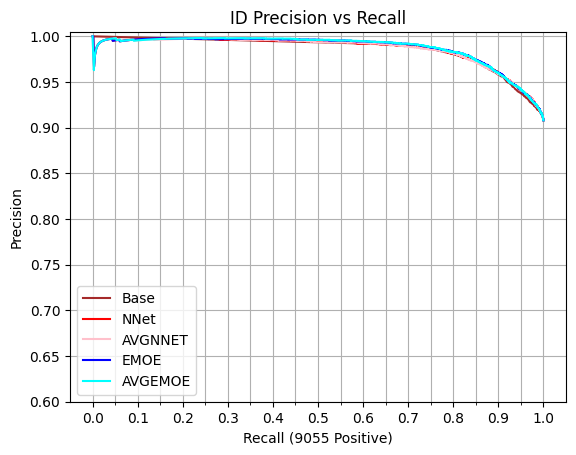

In [ ]:
# plot id
###########
base_predictions = predictions_dict['heldid_base']
model_predictions = predictions_dict['heldid_model_net']
average_model_predictions = predictions_dict['heldid_avg_model_net']
true_Y = predictions_dict['heldid_Y']

plt.figure()

# base model
confs = np.mean(base_predictions, -1)
preds = (confs >.5)
precision, recall, thresholds = metrics.precision_recall_curve(true_Y, confs)
plt.plot(recall, precision, c='brown')
BASE_AUPRC = auprc_threshs(confs, true_Y, AUCTHRESHS)
BASE_AUROC = metrics.roc_auc_score(true_Y, confs)
BASE_ACC = metrics.accuracy_score(true_Y, preds)

print('Base:\n{} (AUROC:{},ACC:{})'.format(BASE_AUPRC, BASE_AUROC,BASE_ACC))

# student model
confs = np.mean(model_predictions, -1)
preds = (confs >.5)
precision, recall, thresholds = metrics.precision_recall_curve(true_Y, confs)
plt.plot(recall, precision, c='red')
MOD_AUPRC = auprc_threshs(confs, true_Y, AUCTHRESHS)
MOD_AUROC = metrics.roc_auc_score(true_Y, confs)
MOD_ACC = metrics.accuracy_score(true_Y, preds)
print('Model:\n{} (AUROC:{},ACC:{})'.format(MOD_AUPRC, MOD_AUROC,MOD_ACC))

# average student model
confs = np.mean(average_model_predictions, -1)
preds = (confs >.5)
precision, recall, thresholds = metrics.precision_recall_curve(true_Y, confs)
plt.plot(recall, precision, c='pink')
AVGMOD_AUPRC = auprc_threshs(confs, true_Y, AUCTHRESHS)
AVGMOD_AUROC = metrics.roc_auc_score(true_Y, confs)
AVGMOD_ACC = metrics.accuracy_score(true_Y, preds)
print('Average Model:\n{} (AUROC:{},ACC:{})'.format(AVGMOD_AUPRC, AVGMOD_AUROC,AVGMOD_ACC))

# base+student model
confs = (np.mean(base_predictions, -1)+np.mean(model_predictions, -1))/2.
preds = (confs >.5)
precision, recall, thresholds = metrics.precision_recall_curve(true_Y, confs)
plt.plot(recall, precision, c='blue')
EMOE_AUPRC = auprc_threshs(confs, true_Y, AUCTHRESHS)
EMOE_AUROC = metrics.roc_auc_score(true_Y, confs)
EMOE_ACC = metrics.accuracy_score(true_Y, preds)
print('Base+Model:\n{} (AUROC:{},ACC:{})'.format(EMOE_AUPRC, EMOE_AUROC,EMOE_ACC))

# base+average student model
confs = (np.mean(base_predictions, -1)+np.mean(average_model_predictions, -1))/2.
preds = (confs >.5)
precision, recall, thresholds = metrics.precision_recall_curve(true_Y, confs)
plt.plot(recall, precision, c='cyan')
AVGEMOE_AUPRC = auprc_threshs(confs, true_Y, AUCTHRESHS)
AVGEMOE_AUROC = metrics.roc_auc_score(true_Y, confs)
AVGEMOE_ACC = metrics.accuracy_score(true_Y, preds)
print('Base+Average Model:\n{} (AUROC:{},ACC:{})'.format(AVGEMOE_AUPRC, AVGEMOE_AUROC,AVGEMOE_ACC))

plt.xticks(np.arange(0, 1.01, step=0.1))
plt.xticks(np.arange(0, 1.01, step=0.05), minor=True)
plt.yticks(np.arange(0.6, 1.01, step=0.05))
plt.grid(True, which='both')
plt.xlabel('Recall ({} Positive)'.format(int(np.sum(true_Y))))
plt.ylabel('Precision')
plt.title('ID Precision vs Recall')
plt.legend(['Base', 'NNet', 'AVGNNET', 'EMOE', 'AVGEMOE'])
plt.show()

In [ ]:
results_dict['heldid_base_AUPRC'] = BASE_AUPRC
results_dict['heldid_model_AUPRC'] = MOD_AUPRC
results_dict['heldid_avg_model_AUPRC'] = AVGMOD_AUPRC
results_dict['heldid_emoe_AUPRC'] = EMOE_AUPRC
results_dict['heldid_avg_emoe_AUPRC'] = AVGEMOE_AUPRC

results_dict['heldid_base_AUROC'] = BASE_AUROC
results_dict['heldid_model_AUROC'] = MOD_AUROC
results_dict['heldid_avg_model_AUROC'] = AVGMOD_AUROC
results_dict['heldid_emoe_AUROC'] = EMOE_AUROC
results_dict['heldid_avg_emoe_AUROC'] = AVGEMOE_AUROC

Base:
[0.98978626 0.97957253 0.97123953 0.96371758 0.91160392] (AUROC:0.7001263008870153,ACC:0.8158820346320347)
Model:
[0.99526782 0.98351106 0.9717482  0.96185949 0.91175095] (AUROC:0.7037347245016448,ACC:0.8129058441558441)
Average Model:
[0.9943343  0.98104533 0.96850787 0.95951256 0.91021444] (AUROC:0.7008675004302957,ACC:0.8112824675324676)
Base+Model:
[0.99475699 0.98678272 0.97869601 0.96982057 0.91588921] (AUROC:0.7109260570123659,ACC:0.8157467532467533)
Base+Average Model:
[0.99437379 0.98658581 0.97890026 0.96988944 0.91573644] (AUROC:0.7102346142004863,ACC:0.8156114718614719)


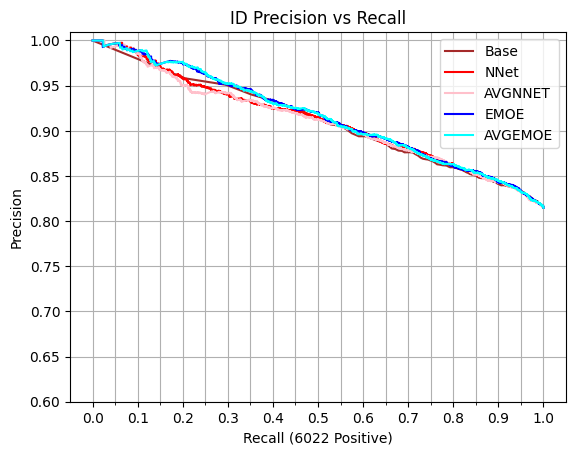

In [ ]:
# plot ood
###########
base_predictions = predictions_dict['heldood_base']
model_predictions = predictions_dict['heldood_model_net']
average_model_predictions = predictions_dict['heldood_avg_model_net']
true_Y = predictions_dict['heldood_Y']

plt.figure()

# base model
confs = np.mean(base_predictions, -1)
preds = (confs >.5)
precision, recall, thresholds = metrics.precision_recall_curve(true_Y, confs)
plt.plot(recall, precision, c='brown')
BASE_AUPRC = auprc_threshs(confs, true_Y, AUCTHRESHS)
BASE_AUROC = metrics.roc_auc_score(true_Y, confs)
BASE_ACC = metrics.accuracy_score(true_Y, preds)

print('Base:\n{} (AUROC:{},ACC:{})'.format(BASE_AUPRC, BASE_AUROC,BASE_ACC))

# student model
confs = np.mean(model_predictions, -1)
preds = (confs >.5)
precision, recall, thresholds = metrics.precision_recall_curve(true_Y, confs)
plt.plot(recall, precision, c='red')
MOD_AUPRC = auprc_threshs(confs, true_Y, AUCTHRESHS)
MOD_AUROC = metrics.roc_auc_score(true_Y, confs)
MOD_ACC = metrics.accuracy_score(true_Y, preds)
print('Model:\n{} (AUROC:{},ACC:{})'.format(MOD_AUPRC, MOD_AUROC,MOD_ACC))

# average student model
confs = np.mean(average_model_predictions, -1)
preds = (confs >.5)
precision, recall, thresholds = metrics.precision_recall_curve(true_Y, confs)
plt.plot(recall, precision, c='pink')
AVGMOD_AUPRC = auprc_threshs(confs, true_Y, AUCTHRESHS)
AVGMOD_AUROC = metrics.roc_auc_score(true_Y, confs)
AVGMOD_ACC = metrics.accuracy_score(true_Y, preds)
print('Average Model:\n{} (AUROC:{},ACC:{})'.format(AVGMOD_AUPRC, AVGMOD_AUROC,AVGMOD_ACC))

# base+student model
confs = (np.mean(base_predictions, -1)+np.mean(model_predictions, -1))/2.
preds = (confs >.5)
precision, recall, thresholds = metrics.precision_recall_curve(true_Y, confs)
plt.plot(recall, precision, c='blue')
EMOE_AUPRC = auprc_threshs(confs, true_Y, AUCTHRESHS)
EMOE_AUROC = metrics.roc_auc_score(true_Y, confs)
EMOE_ACC = metrics.accuracy_score(true_Y, preds)
print('Base+Model:\n{} (AUROC:{},ACC:{})'.format(EMOE_AUPRC, EMOE_AUROC,EMOE_ACC))

# base+average student model
confs = (np.mean(base_predictions, -1)+np.mean(average_model_predictions, -1))/2.
preds = (confs >.5)
precision, recall, thresholds = metrics.precision_recall_curve(true_Y, confs)
plt.plot(recall, precision, c='cyan')
AVGEMOE_AUPRC = auprc_threshs(confs, true_Y, AUCTHRESHS)
AVGEMOE_AUROC = metrics.roc_auc_score(true_Y, confs)
AVGEMOE_ACC = metrics.accuracy_score(true_Y, preds)
print('Base+Average Model:\n{} (AUROC:{},ACC:{})'.format(AVGEMOE_AUPRC, AVGEMOE_AUROC,AVGEMOE_ACC))

plt.xticks(np.arange(0, 1.01, step=0.1))
plt.xticks(np.arange(0, 1.01, step=0.05), minor=True)
plt.yticks(np.arange(0.6, 1.01, step=0.05))
plt.grid(True, which='both')
plt.xlabel('Recall ({} Positive)'.format(int(np.sum(true_Y))))
plt.ylabel('Precision')
plt.title('ID Precision vs Recall')
plt.legend(['Base', 'NNet', 'AVGNNET', 'EMOE', 'AVGEMOE'])
plt.show()

In [ ]:
results_dict['heldood_base_AUPRC'] = BASE_AUPRC
results_dict['heldood_model_AUPRC'] = MOD_AUPRC
results_dict['heldood_avg_model_AUPRC'] = AVGMOD_AUPRC
results_dict['heldood_emoe_AUPRC'] = EMOE_AUPRC
results_dict['heldood_avg_emoe_AUPRC'] = AVGEMOE_AUPRC

results_dict['heldood_base_AUROC'] = BASE_AUROC
results_dict['heldood_model_AUROC'] = MOD_AUROC
results_dict['heldood_avg_model_AUROC'] = AVGMOD_AUROC
results_dict['heldood_emoe_AUROC'] = EMOE_AUROC
results_dict['heldood_avg_emoe_AUROC'] = AVGEMOE_AUROC

results_dict['heldood_base_ACC'] = BASE_ACC
results_dict['heldood_model_ACC'] = MOD_ACC
results_dict['heldood_avg_model_ACC'] = AVGMOD_ACC
results_dict['heldood_emoe_ACC'] = EMOE_ACC
results_dict['heldood_avg_emoe_ACC'] = AVGEMOE_ACC

In [ ]:
with open(os.path.join(save_path, 'results.p'), 'wb') as f:
    pickle.dump(results_dict, f)